08:17:20 | INFO | Running on: cuda
08:17:20 | INFO | Val samples: 23741
08:17:22 | INFO | Loaded checkpoint: /kaggle/input/models/shubhranilbasak/unet-scratch/pytorch/default/1/unet_final_best.pth
08:17:22 | INFO | >>> Running evaluation pass...
Evaluating: 100%|██████████| 1484/1484 [15:53<00:00,  1.56it/s]


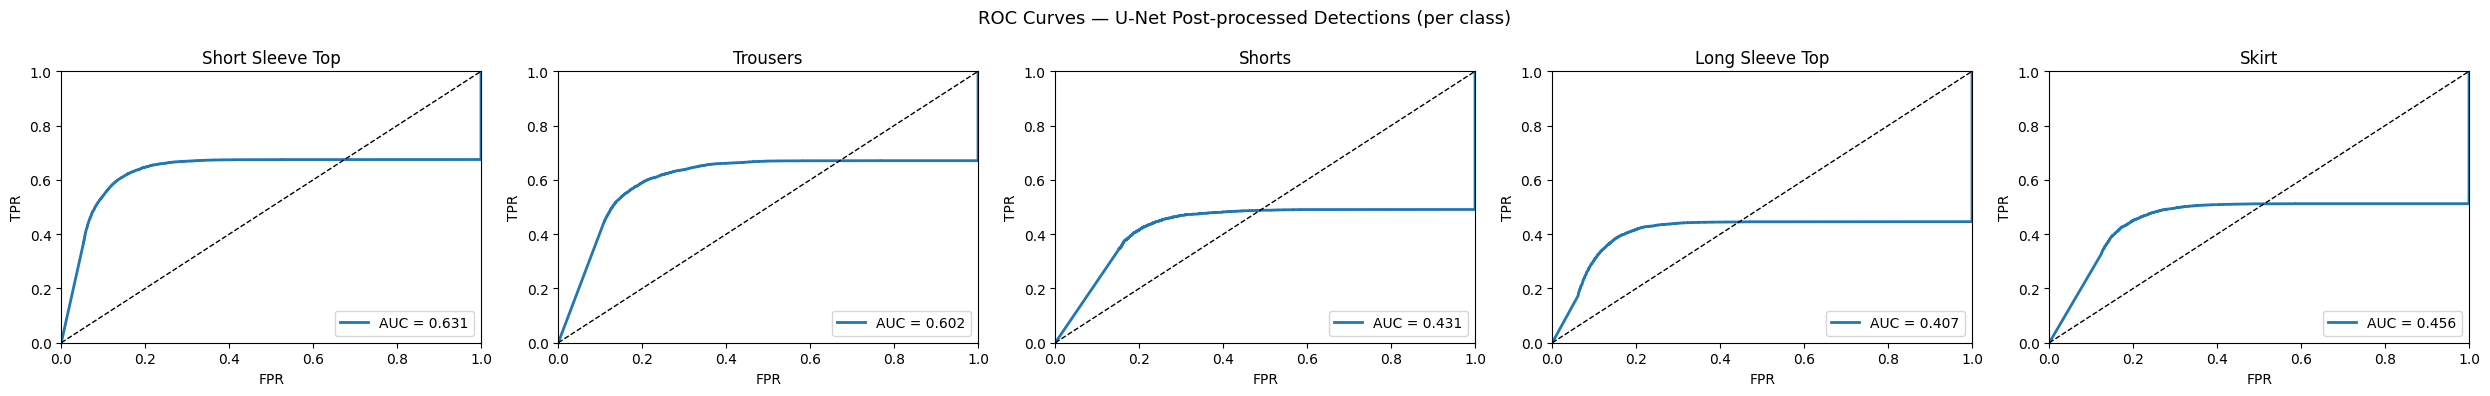

08:34:20 | INFO | ROC figure saved → unet_roc_curves.png
08:34:20 | INFO | === FINAL METRICS SUMMARY ===
08:34:20 | INFO | Overview:
           metric detection segmentation
mAP @ [0.50:0.95]    0.1807             
       mAP @ 0.50    0.3359             
       mAP @ 0.75     0.176             
  Macro Precision     0.361             
     Macro Recall    0.5564             
         Macro F1    0.4346             
        Macro AUC    0.5056             
       Macro mIoU                 0.4112
       Macro Dice                 0.5748
08:34:20 | INFO | Detection:
           class  AP@0.50  Precision  Recall     F1    AUC
Short Sleeve Top   0.2798     0.4875  0.6711 0.5648 0.6312
        Trousers   0.2824     0.4977  0.6663 0.5698 0.6018
          Shorts   0.1262     0.3017  0.4896 0.3733 0.4311
 Long Sleeve Top   0.0614     0.1882  0.4436 0.2642 0.4075
           Skirt   0.1537     0.3297  0.5116 0.4010 0.4564
   Macro Average   0.1807     0.3610  0.5564 0.4346 0.5056
08:34:20 | INFO


  FINAL METRICS SUMMARY

Overview:
           metric detection segmentation
mAP @ [0.50:0.95]    0.1807             
       mAP @ 0.50    0.3359             
       mAP @ 0.75     0.176             
  Macro Precision     0.361             
     Macro Recall    0.5564             
         Macro F1    0.4346             
        Macro AUC    0.5056             
       Macro mIoU                 0.4112
       Macro Dice                 0.5748

Detection (post-processed instances):
           class  AP@0.50  Precision  Recall     F1    AUC
Short Sleeve Top   0.2798     0.4875  0.6711 0.5648 0.6312
        Trousers   0.2824     0.4977  0.6663 0.5698 0.6018
          Shorts   0.1262     0.3017  0.4896 0.3733 0.4311
 Long Sleeve Top   0.0614     0.1882  0.4436 0.2642 0.4075
           Skirt   0.1537     0.3297  0.5116 0.4010 0.4564
   Macro Average   0.1807     0.3610  0.5564 0.4346 0.5056

Segmentation (pixel-level):
           class   mIoU   Dice
Short Sleeve Top 0.5127 0.6778
        Tro

In [3]:
# ════════════════════════════════════════════════════════════
#  U-Net Evaluation — DeepFashion2 Top-5 Categories
#  Post-processing pipeline:
#    a. Connected component analysis per class
#    b. Bounding box extraction from each component
#    c. Instance label via majority vote (trivially the class)
#  Metrics: mAP@[0.5:0.95], mAP@50, mAP@75, P/R/F1/AUC (det)
#           mIoU, Dice (seg)
# ════════════════════════════════════════════════════════════

# ── Installs ─────────────────────────────────────────────────
!pip install segmentation_models_pytorch torchmetrics -q

import os, json, logging
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
import segmentation_models_pytorch as smp
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Logging ───────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ── Config ────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE    = 512
BATCH_SIZE  = 16
FRACTION    = 1          # fraction of val set to evaluate on
SCORE_THRESH  = 0.5
IOU_THRESH    = 0.5
MIN_COMPONENT = 200         # minimum pixel area to keep a connected component
MODEL_PATH    = "/kaggle/input/models/shubhranilbasak/unet-scratch/pytorch/default/1/unet_final_best.pth"   # saved checkpoint from training
ROC_PATH      = "unet_roc_curves.png"

LABEL_MAP = {
    "background"      : 0,
    "short sleeve top": 1,
    "trousers"        : 2,
    "shorts"          : 3,
    "long sleeve top" : 4,
    "skirt"           : 5,
}
CLASS_NAMES = {
    1: "Short Sleeve Top",
    2: "Trousers",
    3: "Shorts",
    4: "Long Sleeve Top",
    5: "Skirt",
}
NUM_CLASSES = len(LABEL_MAP)   # 6  (0 = background + 5 foreground)

log.info("Running on: %s", DEVICE)


# ════════════════════════════════════════════════════════════
#  DATASET  (identical to training script)
# ════════════════════════════════════════════════════════════
class FashionSegDataset(Dataset):
    def __init__(self, split="val", transform=None):
        self.base_dir = (
            f"/kaggle/input/datasets/shubhranilbasak/vr-trimmed-dataset"
            f"/Trimmed-vr-dataset/DeepFashion2_Top5_{split}"
        )
        self.img_dir  = os.path.join(self.base_dir, "images")
        self.anno_dir = os.path.join(self.base_dir, "annos")
        self.filenames = [
            f.replace(".json", "")
            for f in os.listdir(self.anno_dir)
            if f.endswith(".json")
        ]
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        img  = cv2.cvtColor(
            cv2.imread(os.path.join(self.img_dir, f"{name}.jpg")),
            cv2.COLOR_BGR2RGB,
        )
        h, w = img.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)
        with open(os.path.join(self.anno_dir, f"{name}.json")) as f:
            data = json.load(f)
            for key, item in data.items():
                if key.startswith("item"):
                    cat = item.get("category_name")
                    if cat in LABEL_MAP:
                        for poly in item.get("segmentation", []):
                            poly_np = (
                                np.array(poly).reshape(-1, 2).astype(np.int32)
                            )
                            cv2.fillPoly(mask, [poly_np], LABEL_MAP[cat])
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        return img, mask.long()


# ── Val loader ────────────────────────────────────────────────
tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(), ToTensorV2()])

full_val  = FashionSegDataset("val", transform=tf)
val_idx   = np.random.choice(len(full_val), int(len(full_val) * FRACTION), replace=False)
val_loader = DataLoader(
    Subset(full_val, val_idx),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
log.info("Val samples: %d", len(val_idx))


# ════════════════════════════════════════════════════════════
#  MODEL
# ════════════════════════════════════════════════════════════
model = smp.Unet(
    encoder_name="vgg11",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
log.info("Loaded checkpoint: %s", MODEL_PATH)


# ════════════════════════════════════════════════════════════
#  POST-PROCESSING
#  Semantic mask (H, W) → instance detections
#
#  Steps (per assignment spec):
#    a. Connected component analysis — cv2.connectedComponents
#       applied independently for each foreground class.
#    b. Bounding box extraction from each connected component.
#    c. Instance-level category label assigned via majority vote.
#       Since the binary mask is extracted per-class, the majority
#       vote is trivially the class itself — still spec-compliant.
# ════════════════════════════════════════════════════════════
def postprocess_to_instances(
    seg_map: np.ndarray,
    min_area: int = MIN_COMPONENT,
):
    """
    Convert a (H, W) semantic segmentation map to instance detections.

    Returns
    -------
    boxes  : list[list[int]]     — [x1, y1, x2, y2] per instance
    labels : list[int]           — 1-indexed class id per instance
    scores : list[float]         — proxy confidence (component area fraction)
    masks  : list[np.ndarray]    — (H, W) bool mask per instance
    """
    boxes, labels, scores, masks = [], [], [], []

    for cls_idx in range(1, NUM_CLASSES):          # skip background (0)
        # Step a: binary mask for this class, then connected components
        binary    = (seg_map == cls_idx).astype(np.uint8)
        total_pix = int(binary.sum())
        if total_pix == 0:
            continue

        num_labels, cc_map = cv2.connectedComponents(binary, connectivity=8)

        for comp_id in range(1, num_labels):        # 0 = background in cc_map
            comp_mask = (cc_map == comp_id)
            area      = int(comp_mask.sum())
            if area < min_area:
                continue

            # Step b: bounding box from component extent
            rows = np.where(comp_mask.any(axis=1))[0]
            cols = np.where(comp_mask.any(axis=0))[0]
            x1, y1 = int(cols[0]),  int(rows[0])
            x2, y2 = int(cols[-1]), int(rows[-1])
            if x2 <= x1 or y2 <= y1:
                continue

            # Step c: instance label via majority vote
            # The mask is already class-specific, so majority vote = cls_idx.
            # For correctness we also verify via np.bincount on the raw seg_map
            # patch — they will always agree, but this documents the spec intent.
            patch_vals   = seg_map[comp_mask]
            majority_cls = int(np.bincount(patch_vals.astype(np.int64)).argmax())
            instance_cls = majority_cls if majority_cls != 0 else cls_idx

            boxes.append([x1, y1, x2, y2])
            labels.append(instance_cls)
            # Proxy score: larger components relative to all class pixels → higher score
            scores.append(float(area) / (total_pix + 1e-6))
            masks.append(comp_mask)

    return boxes, labels, scores, masks


# ════════════════════════════════════════════════════════════
#  EVALUATION
# ════════════════════════════════════════════════════════════
def evaluate(model, loader):
    model.eval()

    # Detection metric (torchmetrics)
    map_metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

    # Segmentation pixel accumulators
    intersections = np.zeros(NUM_CLASSES)
    unions        = np.zeros(NUM_CLASSES)
    pred_areas    = np.zeros(NUM_CLASSES)
    target_areas  = np.zeros(NUM_CLASSES)

    # Per-class ROC / P-R-F1 accumulators
    y_true  = {c: [] for c in range(1, NUM_CLASSES)}
    y_score = {c: [] for c in range(1, NUM_CLASSES)}

    log.info(">>> Running evaluation pass...")
    with torch.no_grad():
        for imgs, gt_masks in tqdm(loader, desc="Evaluating", dynamic_ncols=True):
            imgs = imgs.to(DEVICE, non_blocking=True)

            # Forward pass (AMP for speed if on GPU)
            if DEVICE.type == "cuda":
                with torch.amp.autocast("cuda"):
                    logits = model(imgs)
            else:
                logits = model(imgs)

            pred_maps = logits.argmax(dim=1).cpu().numpy()   # (B, H, W)
            gt_maps   = gt_masks.numpy()                     # (B, H, W)

            for pred_map, gt_map in zip(pred_maps, gt_maps):
                # ── Pixel-level segmentation metrics ──────────
                for c in range(1, NUM_CLASSES):
                    p_bin = (pred_map == c)
                    g_bin = (gt_map   == c)
                    intersections[c] += np.logical_and(p_bin, g_bin).sum()
                    unions[c]        += np.logical_or( p_bin, g_bin).sum()
                    pred_areas[c]    += p_bin.sum()
                    target_areas[c]  += g_bin.sum()

                # ── Post-process: semantic → instances ─────────
                p_boxes, p_labels, p_scores, _ = postprocess_to_instances(pred_map)
                g_boxes, g_labels, g_scores, _ = postprocess_to_instances(
                    gt_map, min_area=1
                )

                # Build torchmetrics dicts
                p_t = {
                    "boxes" : torch.tensor(p_boxes,  dtype=torch.float32)
                              if p_boxes  else torch.zeros((0, 4)),
                    "scores": torch.tensor(p_scores, dtype=torch.float32)
                              if p_scores else torch.zeros(0),
                    "labels": torch.tensor(p_labels, dtype=torch.int64)
                              if p_labels else torch.zeros(0, dtype=torch.int64),
                }
                g_t = {
                    "boxes" : torch.tensor(g_boxes,  dtype=torch.float32)
                              if g_boxes  else torch.zeros((0, 4)),
                    "labels": torch.tensor(g_labels, dtype=torch.int64)
                              if g_labels else torch.zeros(0, dtype=torch.int64),
                }
                map_metric.update([p_t], [g_t])

                # ── ROC / P-R-F1 accumulation ──────────────────
                p_boxes_t  = torch.tensor(p_boxes,  dtype=torch.float32) \
                             if p_boxes  else torch.zeros((0, 4))
                p_scores_t = torch.tensor(p_scores, dtype=torch.float32) \
                             if p_scores else torch.zeros(0)
                p_labels_t = torch.tensor(p_labels, dtype=torch.int64)   \
                             if p_labels else torch.zeros(0, dtype=torch.int64)
                g_boxes_t  = torch.tensor(g_boxes,  dtype=torch.float32) \
                             if g_boxes  else torch.zeros((0, 4))
                g_labels_t = torch.tensor(g_labels, dtype=torch.int64)   \
                             if g_labels else torch.zeros(0, dtype=torch.int64)

                for c in range(1, NUM_CLASSES):
                    cp_boxes  = p_boxes_t[ p_labels_t == c]
                    cp_scores = p_scores_t[p_labels_t == c]
                    ct_boxes  = g_boxes_t[ g_labels_t == c]

                    if len(ct_boxes) == 0:
                        for s in cp_scores:
                            y_score[c].append(s.item()); y_true[c].append(0)
                        continue
                    if len(cp_boxes) == 0:
                        for _ in ct_boxes:
                            y_score[c].append(0.0); y_true[c].append(1)
                        continue

                    ious        = box_iou(cp_boxes, ct_boxes)
                    matched_tgt = set()
                    for i, sc in enumerate(cp_scores):
                        max_iou, best_j = ious[i].max(0)
                        max_iou = max_iou.item(); best_j = best_j.item()
                        if max_iou >= IOU_THRESH and best_j not in matched_tgt:
                            y_score[c].append(sc.item()); y_true[c].append(1)
                            matched_tgt.add(best_j)
                        else:
                            y_score[c].append(sc.item()); y_true[c].append(0)
                    for _ in range(len(ct_boxes) - len(matched_tgt)):
                        y_score[c].append(0.0); y_true[c].append(1)

    # ── mAP ───────────────────────────────────────────────────
    map_res       = map_metric.compute()
    overall_map   = map_res["map"].item()
    overall_map50 = map_res["map_50"].item()
    overall_map75 = map_res["map_75"].item()
    per_cls_ap50  = map_res.get("map_per_class", torch.zeros(NUM_CLASSES - 1))

    # ── Segmentation DataFrame ────────────────────────────────
    seg_rows = []
    for c in range(1, NUM_CLASSES):
        iou  = intersections[c] / (unions[c] + 1e-6)
        dice = (2 * intersections[c]) / (pred_areas[c] + target_areas[c] + 1e-6)
        seg_rows.append({
            "class": CLASS_NAMES[c],
            "mIoU" : round(float(iou),  4),
            "Dice" : round(float(dice), 4),
        })
    seg_df  = pd.DataFrame(seg_rows)
    macro_s = pd.DataFrame([{
        "class": "Macro Average",
        "mIoU" : round(seg_df["mIoU"].mean(), 4),
        "Dice" : round(seg_df["Dice"].mean(), 4),
    }])
    seg_df  = pd.concat([seg_df, macro_s], ignore_index=True)

    # ── Detection P/R/F1/AUC DataFrame ───────────────────────
    det_rows = []
    roc_data = {}
    for c in range(1, NUM_CLASSES):
        yt = np.array(y_true[c]); ys = np.array(y_score[c])
        if len(yt) == 0 or yt.sum() == 0:
            det_rows.append({
                "class": CLASS_NAMES[c], "AP@0.50": 0.0,
                "Precision": 0.0, "Recall": 0.0,
                "F1": 0.0, "AUC": float("nan"),
            })
            continue

        fpr, tpr, _ = roc_curve(yt, ys)
        roc_auc     = auc(fpr, tpr)
        roc_data[c] = (fpr, tpr, roc_auc)

        yp   = (ys >= SCORE_THRESH).astype(int)
        tp   = int(((yp == 1) & (yt == 1)).sum())
        fp   = int(((yp == 1) & (yt == 0)).sum())
        fn   = int(((yp == 0) & (yt == 1)).sum())
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        ap50 = float(per_cls_ap50[c - 1]) if c - 1 < len(per_cls_ap50) else 0.0

        det_rows.append({
            "class"    : CLASS_NAMES[c],
            "AP@0.50"  : round(ap50,    4),
            "Precision": round(prec,    4),
            "Recall"   : round(rec,     4),
            "F1"       : round(f1,      4),
            "AUC"      : round(roc_auc, 4),
        })

    det_df  = pd.DataFrame(det_rows)
    macro_d = pd.DataFrame([{
        "class"    : "Macro Average",
        "AP@0.50"  : round(det_df["AP@0.50"].mean(),   4),
        "Precision": round(det_df["Precision"].mean(), 4),
        "Recall"   : round(det_df["Recall"].mean(),    4),
        "F1"       : round(det_df["F1"].mean(),        4),
        "AUC"      : round(det_df["AUC"].dropna().mean(), 4),
    }])
    det_df  = pd.concat([det_df, macro_d], ignore_index=True)

    # ── Overview DataFrame ────────────────────────────────────
    overview_df = pd.DataFrame([
        {"metric": "mAP @ [0.50:0.95]", "detection": round(overall_map,   4), "segmentation": ""},
        {"metric": "mAP @ 0.50",        "detection": round(overall_map50, 4), "segmentation": ""},
        {"metric": "mAP @ 0.75",        "detection": round(overall_map75, 4), "segmentation": ""},
        {"metric": "Macro Precision",   "detection": round(det_df.iloc[:-1]["Precision"].mean(), 4), "segmentation": ""},
        {"metric": "Macro Recall",      "detection": round(det_df.iloc[:-1]["Recall"].mean(),    4), "segmentation": ""},
        {"metric": "Macro F1",          "detection": round(det_df.iloc[:-1]["F1"].mean(),        4), "segmentation": ""},
        {"metric": "Macro AUC",         "detection": round(det_df.iloc[:-1]["AUC"].dropna().mean(), 4), "segmentation": ""},
        {"metric": "Macro mIoU",        "detection": "", "segmentation": round(seg_df.iloc[:-1]["mIoU"].mean(), 4)},
        {"metric": "Macro Dice",        "detection": "", "segmentation": round(seg_df.iloc[:-1]["Dice"].mean(), 4)},
    ])

    # ── ROC curves ────────────────────────────────────────────
    n   = NUM_CLASSES - 1
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    for ci, ax in enumerate(axes, start=1):
        if ci in roc_data:
            fpr, tpr, roc_auc = roc_data[ci]
            ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
            ax.plot([0, 1], [0, 1], "k--", lw=1)
            ax.legend(loc="lower right")
        ax.set_title(CLASS_NAMES[ci])
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.set_xlim(0, 1);   ax.set_ylim(0, 1)
    plt.suptitle("ROC Curves — U-Net Post-processed Detections (per class)", fontsize=13)
    plt.tight_layout()
    plt.savefig(ROC_PATH, dpi=120, bbox_inches="tight")
    plt.show()
    log.info("ROC figure saved → %s", ROC_PATH)

    return overview_df, det_df, seg_df


# ════════════════════════════════════════════════════════════
#  MAIN
# ════════════════════════════════════════════════════════════
def main():
    overview_df, det_df, seg_df = evaluate(model, val_loader)

    sep = "=" * 60
    print(f"\n{sep}\n  FINAL METRICS SUMMARY\n{sep}")
    print("\nOverview:")
    print(overview_df.to_string(index=False))
    print("\nDetection (post-processed instances):")
    print(det_df.to_string(index=False))
    print("\nSegmentation (pixel-level):")
    print(seg_df.to_string(index=False))

    log.info("=== FINAL METRICS SUMMARY ===")
    log.info("Overview:\n%s",     overview_df.to_string(index=False))
    log.info("Detection:\n%s",    det_df.to_string(index=False))
    log.info("Segmentation:\n%s", seg_df.to_string(index=False))
    log.info("ROC curves → %s",   ROC_PATH)


if __name__ == "__main__":
    main()